# Analise de Doencas Cardiacas -- Heart Failure Prediction Dataset

**Dataset:** Heart Failure Prediction Dataset (Kaggle / UCI)  
**Variavel Alvo:** `HeartDisease` (0 = Sem doenca | 1 = Com doenca)  

### Justificativa da Escolha

O dataset foi selecionado por reunir dados clinicos reais de pacientes, sendo ideal para:
- Analise exploratoria de variaveis quantitativas (idade, pressao, colesterol) e qualitativas (tipo de dor, ECG);
- Tratamento de dados inconsistentes e valores ausentes mascarados como zero;
- Aplicacao do Teorema de Bayes e algoritmos de classificacao para predicao de doencas cardiacas.



## 1. Importacao das Bibliotecas


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score




## 2. Carregamento do Dataset

O dataset foi obtido do [Kaggle -- Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction),  
fruto da combinacao de 5 datasets cardiacos do repositorio UCI Machine Learning.


In [13]:
df = pd.read_csv('heart.csv')
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Tratamento e Limpeza dos Dados

### 3.1 Visao Geral Inicial


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### 3.2 Estatisticas Descritivas Iniciais


In [15]:
df.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 3.3 Identificacao de Problemas

Observacoes nos dados brutos:
- **`Cholesterol`:** 172 registros com valor **0**, o que e biologicamente impossivel (colesterol = 0 mg/dL nao existe em vida). Esses valores representam dados ausentes mascarados.
- **`RestingBP`:** 1 registro com valor **0** (pressao arterial em repouso de 0 e incompativel com vida).
- **`HeartDisease`:** Variavel alvo corretamente binaria (0/1).


In [16]:

print(f"Cholesterol iguais 0: {(df['Cholesterol'] == 0).sum()} registros")
print(f"RestingBP  iguais 0: {(df['RestingBP']  == 0).sum()} registros")
print("\nValores nulos explicitos:")
print(df.isnull().sum())


Cholesterol iguais 0: 172 registros
RestingBP  iguais 0: 1 registros

Valores nulos explicitos:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


### 3.4 Tratamento de Cholesterol -- Imputacao pela Mediana por Sexo

**Justificativa:** Substituir por zero distorceria fortemente medias e correlacoes. A mediana por grupo (Sexo) é preferivel a mediana global pois captura diferencas fisiologicas conhecidas entre homens e mulheres no perfil lipidico, sem ser sensivel a outliers como a media seria.


In [17]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
print(f" Nulos em Cholesterol : {df['Cholesterol'].isnull().sum()}")

 Nulos em Cholesterol : 172


In [18]:

df.groupby('Sex')['Cholesterol'].median()

df['Cholesterol'] = df['Cholesterol'].fillna(
    df.groupby('Sex')['Cholesterol'].transform('median')
)
print(f"\nNulos restantes em Cholesterol: {df['Cholesterol'].isnull().sum()}")



Nulos restantes em Cholesterol: 0


### 3.5 Tratamento de RestingBP -- Imputacao pela Mediana por Sexo

**Justificativa:** Mesmo criterio do Colesterol. Pressao arterial em repouso igual a zero e clinicamente impossivel, sendo um dado ausente mascarado. Imputa-se a mediana por grupo para manter representatividade.


In [19]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].fillna(
    df.groupby('Sex')['RestingBP'].transform('median')
)
print(f"Nulos restantes em RestingBP: {df['RestingBP'].isnull().sum()}")


Nulos restantes em RestingBP: 0


### 3.6 Conversao da Variavel Alvo para Booleano

**Justificativa:** A variavel `HeartDisease` representa um estado binario (tem ou nao tem doenca). Converte-la para `bool` torna o codigo mais legivel e semantico.


In [20]:
df['HeartDisease'] = df['HeartDisease'].astype(bool)
print("Tipo atual:", df["HeartDisease"].dtype)
print(df['HeartDisease'].value_counts())


Tipo atual: bool
HeartDisease
True     508
False    410
Name: count, dtype: int64


### 3.7 Verificação de outliers

In [21]:
for col in df.columns:
    if(df[col].dtype == 'int64' or df[col].dtype == 'float64'):
        mediana=df[col].median()
        media=df[col].mean()
        moda=df[col].mode()[0]
        maximo=df[col].max()
        minimo=df[col].min()
        print(f"{col}:\n-Mediana: {mediana},\n-Média: {media}\n-Moda: {moda},\n-Máximo: {maximo}\n-Mínimo: {minimo}\n")

Age:
-Mediana: 54.0,
-Média: 53.510893246187365
-Moda: 54,
-Máximo: 77
-Mínimo: 28

RestingBP:
-Mediana: 130.0,
-Média: 132.53812636165577
-Moda: 120.0,
-Máximo: 200.0
-Mínimo: 80.0

Cholesterol:
-Mediana: 234.0,
-Média: 242.81045751633988
-Moda: 234.0,
-Máximo: 603.0
-Mínimo: 85.0

FastingBS:
-Mediana: 0.0,
-Média: 0.23311546840958605
-Moda: 0,
-Máximo: 1
-Mínimo: 0

MaxHR:
-Mediana: 138.0,
-Média: 136.80936819172112
-Moda: 150,
-Máximo: 202
-Mínimo: 60

Oldpeak:
-Mediana: 0.6,
-Média: 0.8873638344226579
-Moda: 0.0,
-Máximo: 6.2
-Mínimo: -2.6




**-Todos esses valores são possíveis clinicamente, então não devem ser tratados!**

### 3.8 Verificacao Final da Limpeza


In [22]:
print("=== Nulos apos tratamento ===")
print(df.isnull().sum())
print(f"\nShape final: {df.shape}")
df.describe()


=== Nulos apos tratamento ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Shape final: (918, 12)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,242.810458,0.233115,136.809368,0.887364
std,9.432617,17.990127,53.474043,0.423046,25.460334,1.066570
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,234.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


## 4. Analise Exploratoria de Dados (EDA)

### 4.1 Distribuicao da Variavel Alvo

**Objetivo:** Verificar o balanceamento das classes para entender o contexto da classificacao.


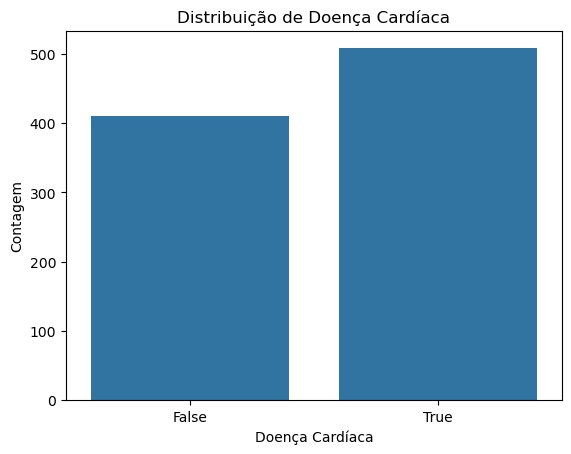

In [23]:
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribuição de Doença Cardíaca')
plt.xlabel('Doença Cardíaca')
plt.ylabel('Contagem')
plt.show()

### 4.2 Distribuicoes das Variaveis Numericas

**Objetivo:** Identificar a forma das distribuicoes separados por grupo alvo.


In [24]:
cores_Bool = {True: 'red', False: 'limegreen'}

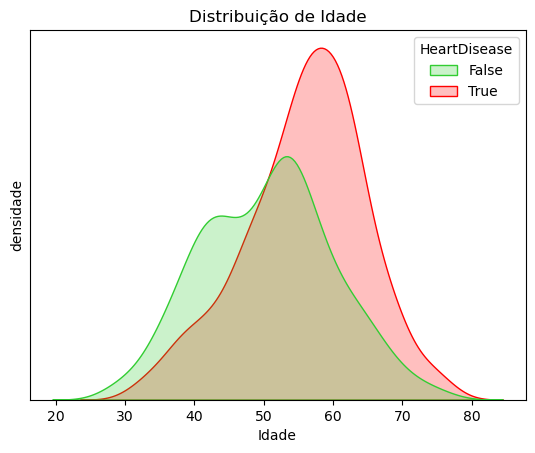

In [25]:

sns.kdeplot(data=df, x='Age', hue='HeartDisease', palette=cores_Bool, fill=True)
plt.title('Distribuição de Idade')
plt.yticks([])
plt.xlabel('Idade')
plt.ylabel('densidade')
plt.show()


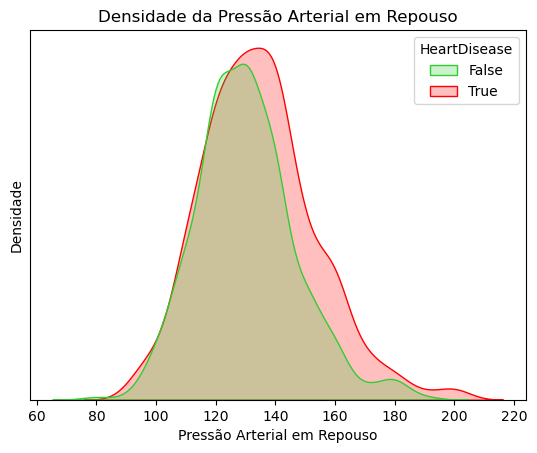

In [26]:

sns.kdeplot(data=df, x='RestingBP', hue='HeartDisease', palette=cores_Bool, fill=True)
plt.title('Densidade da Pressão Arterial em Repouso')
plt.yticks([])
plt.xlabel('Pressão Arterial em Repouso')
plt.ylabel('Densidade')
plt.show()

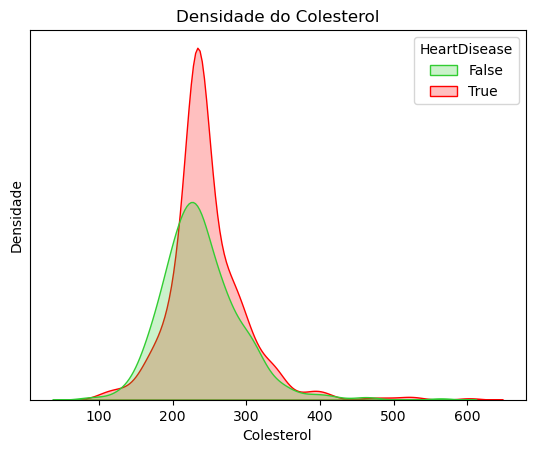

In [27]:
sns.kdeplot(x='Cholesterol', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade do Colesterol')
plt.xlabel('Colesterol')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

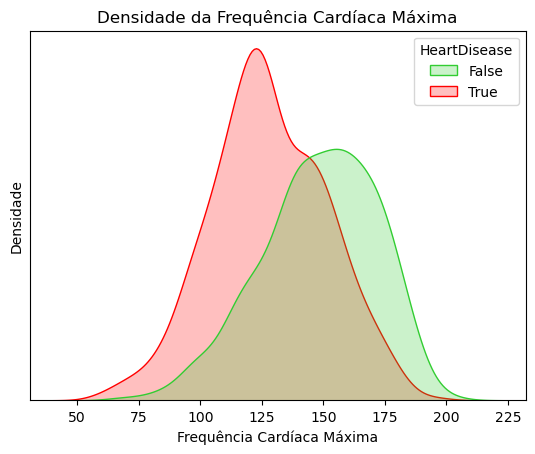

In [28]:
sns.kdeplot(x='MaxHR', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade da Frequência Cardíaca Máxima')
plt.xlabel('Frequência Cardíaca Máxima')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

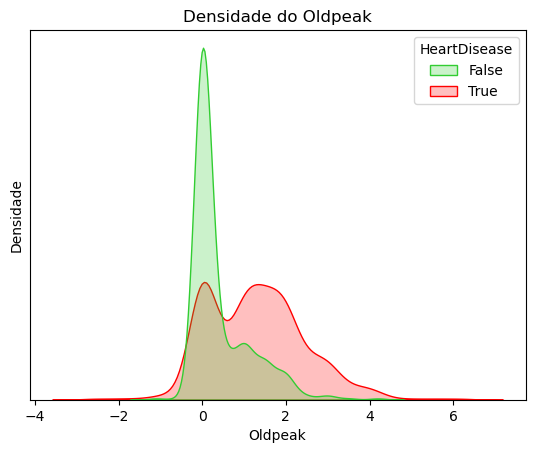

In [29]:
sns.kdeplot(x='Oldpeak', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade do Oldpeak')
plt.xlabel('Oldpeak')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

Text(0, 0.5, 'Densidade')

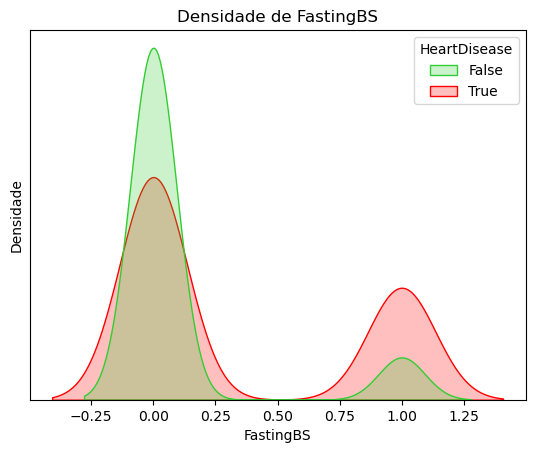

In [30]:
sns.kdeplot(x='FastingBS',hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade de FastingBS')
plt.yticks([])
plt.ylabel('Densidade')

### 4.3 Distribuicoes das Variaveis Quantitativas

**Objetivo:** Identificar a forma das distribuicoes separados por grupo alvo.

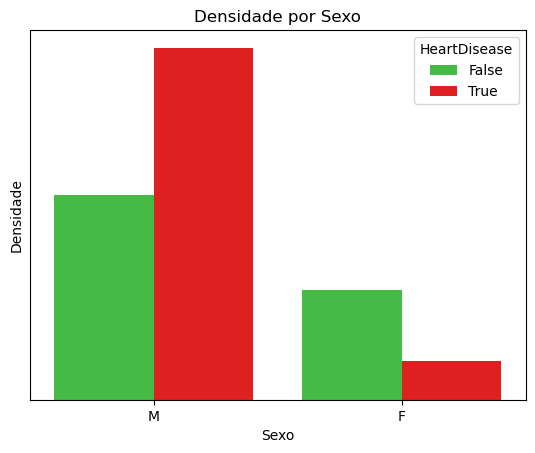

In [31]:
sns.countplot(x='Sex', hue='HeartDisease', data=df, palette=cores_Bool, fill=True)
plt.title('Densidade por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

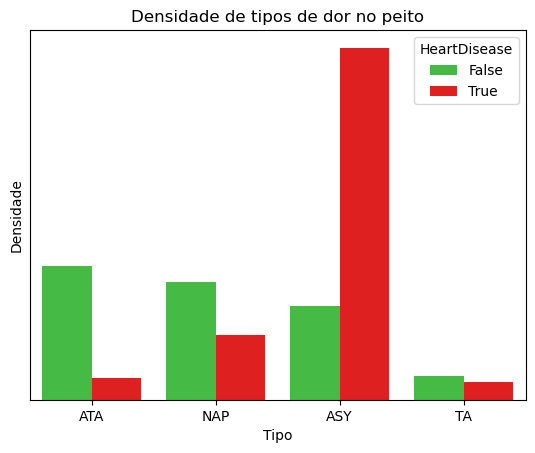

In [32]:
sns.countplot(x='ChestPainType',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)
plt.title('Densidade de tipos de dor no peito')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

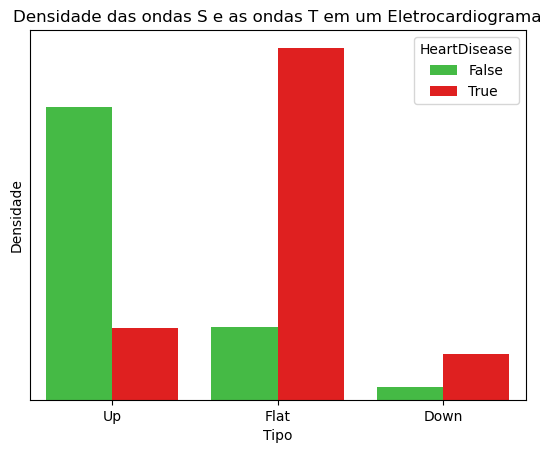

In [33]:
sns.countplot(x='ST_Slope',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)
plt.title('Densidade das ondas S e as ondas T em um Eletrocardiograma')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

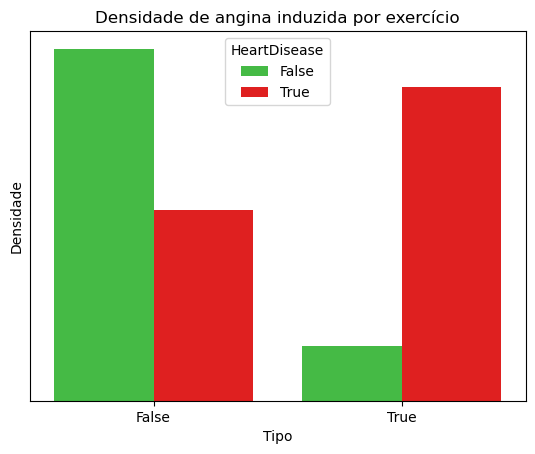

In [34]:
df['ExerciseAngina'] = df['ExerciseAngina'].map({'N': False, 'Y': True})
sns.countplot(x='ExerciseAngina',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)
plt.title('Densidade de angina induzida por exercício')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

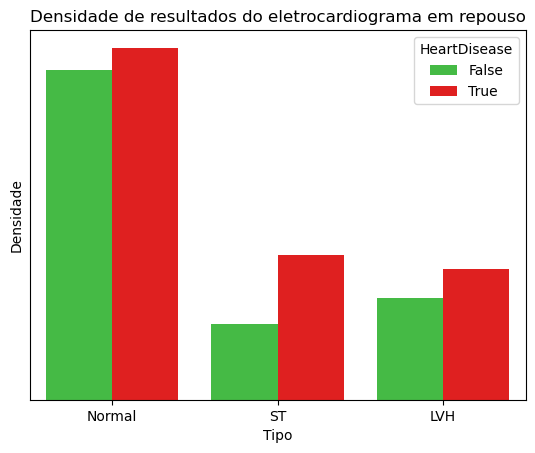

In [35]:
sns.countplot(x='RestingECG',data=df,hue='HeartDisease',palette=cores_Bool,fill=True)  
plt.title('Densidade de resultados do eletrocardiograma em repouso')
plt.xlabel('Tipo')
plt.ylabel('Densidade')
plt.yticks([])
plt.show()

### 4.4 Mapa de correlação ###
**Objetivo: identificar possíves correlações no dataset**

<Axes: >

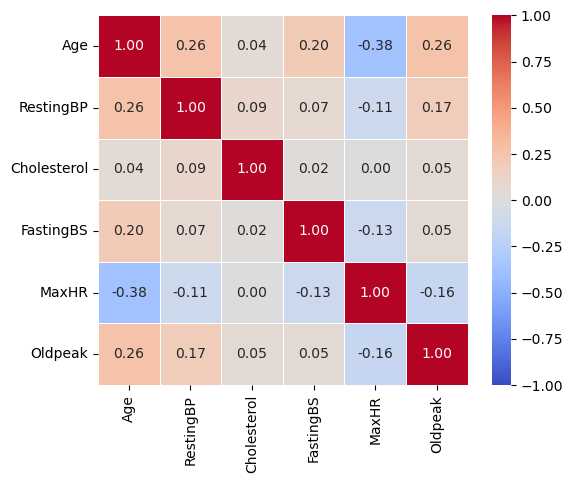

In [36]:

correlacao = df.select_dtypes(include='number').corr()
sns.heatmap(
    correlacao, 
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    vmin=-1, vmax=1,     
    linewidths=0.5,      
    square=True          
)

### 4.5 INSIGHTS GERADOS PELO EDA: ###

* **Oldpeak (Depressão do Segmento ST) — Correlação: +0.40**
    * Pacientes com doença têm um Oldpeak médio de 1,3, comparado a 0,4 nos saudáveis.
    * **Oldpeak > 2:** Taxa de doença altíssima de **91%** (amostra de 100 pacientes).
* **MaxHR (Frequência Cardíaca Máxima) — Correlação: −0.40**
    * Pacientes com doença atingem FC máxima média de 127,7 bpm vs. 148,2 bpm nos saudáveis (uma diferença significativa de ~20 bpm).
    * Esse padrão de déficit cronotrópico se repete inalterado em todas as faixas etárias.
* **ST_Slope (Inclinação do Segmento ST)**
    * **Slope Flat:** 83% de taxa de doença.
    * **Slope Down:** 78% de taxa de doença.
    * **Slope Up:** Apenas 20% de taxa de doença (atua como um forte sinal protetor).
* **ExerciseAngina (Angina induzida por Exercício)**
    * **Com angina:** 85% de taxa de doença.
    * **Sem angina:** 35% de taxa de doença.
* **ChestPainType (Tipo de Dor Torácica)**
    * **ASY (Assintomático):** 79% — O quadro mais perigoso por ser silencioso.
    * **Outros:** ATA: 43%, NAP: 35%, TA: 14%. *(Nota: A dor Típica de Angina - TA - ironicamente apresenta menor taxa que a atípica no geral do dataset)*.
* **FastingBS (Glicemia em Jejum > 120 mg/dL)**
    * **Com elevação:** 79% de taxa de doença vs. 48% sem elevação.

---

## Diferenças por Sexo

* **Homens** têm uma taxa de doença de **63%**, contra **26%** nas **mulheres**.
* **Atenção ao viés amostral:** Há 725 homens e apenas 193 mulheres na base. A amostra feminina é pequena e claramente sub-representada.
* Mesmo o tipo de dor mais perigoso (ASY) tem uma taxa de doença muito diferente: 83% nos homens vs. 56% nas mulheres. Mulheres com dor ASY ainda têm alto risco, mas a diferença ressalta a assimetria do dataset.

---

## Faixa Etária

| Faixa Etária | Taxa de Doença | Observação |
| :--- | :---: | :--- |
| **28–40 anos** | 34% | |
| **41–50 anos** | 42% | |
| **51–60 anos** | 58% | |
| **61–70 anos** | **74%** | **Pico de risco** |
| **71+ anos** | 67% | |

> **Nota:** O risco cresce monotonicamente até os 70 anos. O leve recuo na faixa dos 71+ pode ser atribuído a um **viés de sobrevivência** (pacientes muito frágeis com doença grave podem não chegar a realizar essa avaliação clínica).

---

## Combinações de Risco Críticas

Cruzamentos de variáveis apontam para subgrupos de altíssimo risco:

* **Dor ASY + ExerciseAngina = Y:** 297 pacientes com **90%** de taxa de doença.
* **ST_Slope (Flat ou Down) + ExerciseAngina = Y:** 313 pacientes com **90,7%** de taxa de doença.

### Score de Risco Combinado
Criando um score simples de 0 a 5 com os seguintes fatores críticos: Angina presente, Slope anormal (Flat/Down), Dor ASY, Glicemia alta, e Oldpeak > 1,5.

| Score | Taxa de Doença | N (Pacientes) |
| :---: | :---: | :---: |
| **0** | 4% | 210 |
| **1** | 27% | 168 |
| **2** | 66% | 161 |
| **3** | 87% | 207 |
| **4** | **97%** | 145 |
| **5** | **96%** | 27 |

**Conclusão Clínica:** Pacientes que apresentam 4 ou mais desses fatores têm um risco virtualmente certo (acima de 96%). É uma excelente regra clínica simples extraída dos dados.

---

## Colesterol — O Paradoxo Inverso

* Pacientes com doença têm um colesterol médio **mais baixo (175,9)** do que os pacientes saudáveis (227,1).
* **Por que isso acontece?** Isso é contraintuitivo, mas reflete dois prováveis artefatos dos dados:
    1. Muitos valores "0" foram imputados diretamente para pacientes doentes.
    2. Pacientes com histórico cardíaco frequentemente já estão em tratamento intensivo com hipolipemiantes (estatinas).
* A correlação negativa (−0.23) com a doença deve ser interpretada com extrema cautela pelo modelo.

---

## Insights para Modelagem

* **Feature Selection:** As variáveis `Oldpeak`, `MaxHR`, `ExerciseAngina`, `ST_Slope` e `ChestPainType` são as mais discriminativas da base. Elas devem ter a maior importância (*feature importance*) em qualquer modelo treinado.
* **Escolha do Algoritmo:** O sucesso do *Score de Risco* simples de 5 variáveis na separação das classes sugere que **modelos lineares** (como Regressão Logística) ou **probabilísticos simples** (como Naive Bayes) já terão um excelente desempenho e alta interpretabilidade.
* **Tratamento de Ruído:** O `Cholesterol` com zeros imputados pode estar inserindo ruído nas predições. É recomendado testar o treinamento do modelo com e sem essa variável.
* **Ações recomendadas para o pipeline:**
    * Plotar a Curva ROC-AUC.
    * Extrair o gráfico de *Feature Importance* (ex: de um Random Forest ou XGBoost).
    * Aplicar validação cruzada (Cross-Validation) **estratificada por sexo**, dado o forte desbalanceamento da amostra feminina.

### 5.0 Análise de probabilidade com o Teorema de Bayes

***5.1 PROBABILIDADES A PRIORI P(C)***

In [37]:
classes = [False, True]
features_num = ['Age', 'MaxHR', 'Oldpeak']
features_cat = ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']
total = len(df)
priori = {}

for c in classes:
    priori[c] = (df['HeartDisease'] == c).sum() / total
 
print("Probabilidades A Priori P(C)")
print(f"P(HeartDisease=False) = {priori[False]:.4f} ({priori[False]:.1%})")
print(f"P(HeartDisease=True)  = {priori[True]:.4f} ({priori[True]:.1%})")


Probabilidades A Priori P(C)
P(HeartDisease=False) = 0.4466 (44.7%)
P(HeartDisease=True)  = 0.5534 (55.3%)


**5.2 PARAMETROS GAUSSIANOS (media e desvio por classes)**

In [38]:
params_gauss = {}
print("\n=== Parametros Gaussianos por Classe ===")
for c in classes:
    subset = df[df['HeartDisease'] == c]
    params_gauss[c] = {}
    for feat in features_num:
        mu    = subset[feat].mean()
        sigma = subset[feat].std()
        params_gauss[c][feat] = (mu, sigma)
        print(f"  {feat:10s} | classe={str(c):5s} -> media={mu:.2f}, desvio={sigma:.2f}")


=== Parametros Gaussianos por Classe ===
  Age        | classe=False -> media=50.55, desvio=9.44
  MaxHR      | classe=False -> media=148.15, desvio=23.29
  Oldpeak    | classe=False -> media=0.41, desvio=0.70
  Age        | classe=True  -> media=55.90, desvio=8.73
  MaxHR      | classe=True  -> media=127.66, desvio=23.39
  Oldpeak    | classe=True  -> media=1.27, desvio=1.15


**5.3 PROBABILIDADES CATEGORICAS com Laplace**

In [39]:

probs_cat = {}
print("\n=== Probabilidades Categoricas P(x|C) com Laplace ===")
for c in classes:
    subset = df[df['HeartDisease'] == c]
    probs_cat[c] = {}
    for feat in features_cat:
        k        = df[feat].nunique()   
        contagem = subset[feat].value_counts()
        total_c  = len(subset)
        probs_cat[c][feat] = {}
        for val in df[feat].unique():
            probs_cat[c][feat][val] = (contagem.get(val, 0) + 1) / (total_c + k)
        print(f"  {feat:18s} | classe={str(c):5s} -> {dict(list(probs_cat[c][feat].items())[:2])} ...")
 


=== Probabilidades Categoricas P(x|C) com Laplace ===
  Sex                | classe=False -> {'M': np.float64(0.6504854368932039), 'F': np.float64(0.34951456310679613)} ...
  ChestPainType      | classe=False -> {'ATA': np.float64(0.36231884057971014), 'NAP': np.float64(0.3188405797101449)} ...
  ExerciseAngina     | classe=False -> {np.False_: np.float64(0.8640776699029126), np.True_: np.float64(0.13592233009708737)} ...
  ST_Slope           | classe=False -> {'Up': np.float64(0.7699757869249395), 'Flat': np.float64(0.1937046004842615)} ...
  Sex                | classe=True  -> {'M': np.float64(0.9), 'F': np.float64(0.1)} ...
  ChestPainType      | classe=True  -> {'ATA': np.float64(0.048828125), 'NAP': np.float64(0.142578125)} ...
  ExerciseAngina     | classe=True  -> {np.False_: np.float64(0.3784313725490196), np.True_: np.float64(0.6215686274509804)} ...
  ST_Slope           | classe=True  -> {'Up': np.float64(0.15459882583170254), 'Flat': np.float64(0.7475538160469667)} ...


**5.4 VEROSSIMILHANCA GAUSSIANA**

In [40]:

def verossimilhanca_gaussiana(x, mu, sigma):
    coeficiente = 1.0 / (np.sqrt(2 * np.pi) * sigma)
    expoente    = -((x - mu) ** 2) / (2 * sigma ** 2)
    return coeficiente * np.exp(expoente)

**5.5 FUNCAO DE PREDICAO BAYESIANA**

In [41]:

def prever_bayes(amostra):
    log_posteriors = {}
 
    for c in classes:
        # Inicia com o log da probabilidade a priori
        log_prob = np.log(priori[c])
 
        # Log das verossimilhancas continuas (gaussiana)
        for feat in features_num:
            mu, sigma = params_gauss[c][feat]
            lk = verossimilhanca_gaussiana(amostra[feat], mu, sigma)
            lk = max(lk, 1e-300)   # evitar log(0)
            log_prob += np.log(lk)
 
        # Log das verossimilhancas categoricas (Laplace)
        for feat in features_cat:
            val  = amostra[feat]
            prob = probs_cat[c][feat].get(val, 1e-10)
            log_prob += np.log(prob)
 
        log_posteriors[c] = log_prob
 
    # Converter de log para probabilidade normalizada
    max_log   = max(log_posteriors.values())
    exp_probs = {c: np.exp(log_posteriors[c] - max_log) for c in classes}
    soma      = sum(exp_probs.values())
    return {c: exp_probs[c] / soma for c in classes}
 

**5.6 Aplicação da formúla**

**5.6 Probabilidades A Posteriori P(C|X) -- Aplicacao do Teorema de Bayes**

In [42]:
# Tres perfis de pacientes para aplicar o Teorema de Bayes
pacientes = {
    'Paciente A -- Alto Risco': {
        'Age': 65, 'MaxHR': 110, 'Oldpeak': 2.5,
        'Sex': 'M', 'ChestPainType': 'ASY',
        'ExerciseAngina': False, 'ST_Slope': 'Flat'
    },
    'Paciente B -- Risco Moderado': {
        'Age': 52, 'MaxHR': 138, 'Oldpeak': 1.0,
        'Sex': 'M', 'ChestPainType': 'NAP',
        'ExerciseAngina': False, 'ST_Slope': 'Flat'
    },
    'Paciente C -- Baixo Risco': {
        'Age': 40, 'MaxHR': 165, 'Oldpeak': 0.0,
        'Sex': 'F', 'ChestPainType': 'ATA',
        'ExerciseAngina': False, 'ST_Slope': 'Up'
    },
}

print('O Teorema de Bayes combina a probabilidade a priori P(C)')
print('com a verossimilhanca P(X|C) para gerar a probabilidade')
print('a posteriori P(C|X) -- a probabilidade final do diagnostico.')
print('Formula: P(C|X) proporcional P(C) * P(X|C)')
print('=' * 60)

for nome, paciente in pacientes.items():
    resultado = prever_bayes(paciente)
    pred      = max(resultado, key=resultado.get)
    confianca = resultado[pred]

    print(f'\nPerfil: {nome}')
    print('  Atributos:')
    for k, v in paciente.items():
        print(f'    {k}: {v}')

    print(f'\n  Probabilidades A Posteriori P(C|X):')
    print(f'    P(Sem Doenca | X) = {resultado[False]:.4f}  ({resultado[False]:.1%})')
    print(f'    P(Com Doenca | X) = {resultado[True]:.4f}  ({resultado[True]:.1%})')
    print(f'\n  Predicao: {"COM doenca" if pred else "SEM doenca"}')
    print(f'  Confianca: {confianca:.1%}')

    print('\n  Interpretacao:')
    if pred == True and confianca > 0.85:
        print('    Alta probabilidade de doenca cardiaca.')
        print('    Fatores dominantes: dor assintomatica (ASY),')
        print('    angina por exercicio e declive ST flat/down.')
    elif pred == True and confianca <= 0.85:
        print('    Probabilidade moderada de doenca cardiaca.')
        print('    Evidencias contraditórias -- investigacao adicional recomendada.')
    else:
        print('    Baixa probabilidade de doenca cardiaca.')
        print('    MaxHR elevado, sem angina e ST ascendente (Up)')
        print('    sao indicadores favoraveis.')
    print('-' * 60)


O Teorema de Bayes combina a probabilidade a priori P(C)
com a verossimilhanca P(X|C) para gerar a probabilidade
a posteriori P(C|X) -- a probabilidade final do diagnostico.
Formula: P(C|X) proporcional P(C) * P(X|C)

Perfil: Paciente A -- Alto Risco
  Atributos:
    Age: 65
    MaxHR: 110
    Oldpeak: 2.5
    Sex: M
    ChestPainType: ASY
    ExerciseAngina: False
    ST_Slope: Flat

  Probabilidades A Posteriori P(C|X):
    P(Sem Doenca | X) = 0.0007  (0.1%)
    P(Com Doenca | X) = 0.9993  (99.9%)

  Predicao: COM doenca
  Confianca: 99.9%

  Interpretacao:
    Alta probabilidade de doenca cardiaca.
    Fatores dominantes: dor assintomatica (ASY),
    angina por exercicio e declive ST flat/down.
------------------------------------------------------------

Perfil: Paciente B -- Risco Moderado
  Atributos:
    Age: 52
    MaxHR: 138
    Oldpeak: 1.0
    Sex: M
    ChestPainType: NAP
    ExerciseAngina: False
    ST_Slope: Flat

  Probabilidades A Posteriori P(C|X):
    P(Sem Doenca | 

**5.7 Avaliacao das Metricas -- Naive Bayes no Dataset Completo**

=== Avaliacao -- Naive Bayes (implementado do zero) ===
  Verdadeiros Positivos (TP): 436
  Verdadeiros Negativos (TN): 341
  Falsos Positivos      (FP): 69  <- previu doenca, mas nao tinha
  Falsos Negativos      (FN): 72  <- nao previu doenca, mas tinha

  Acuracia : 0.8464  -- proporcao de acertos totais
  Precisao : 0.8634  -- dos que previu positivo, quantos eram positivos
  Recall   : 0.8583  -- dos que eram positivos, quantos o modelo achou
  F1-Score : 0.8608  -- media harmonica entre precisao e recall


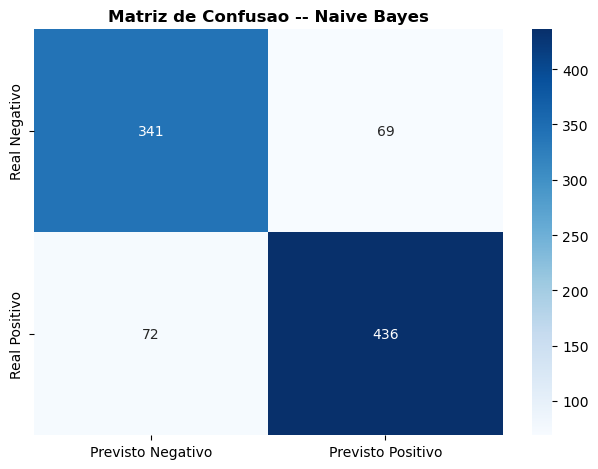

In [43]:
# Aplicar o modelo em todos os registros do dataset
y_pred_bayes = []
for _, row in df.iterrows():
    amostra   = {f: row[f] for f in features_num + features_cat}
    resultado = prever_bayes(amostra)
    y_pred_bayes.append(resultado[True] >= 0.5)

y_pred_bayes = np.array(y_pred_bayes).astype(int)
y_real       = df['HeartDisease'].values.astype(int)

# Calcular metricas do zero
TP = int(((y_pred_bayes == 1) & (y_real == 1)).sum())
TN = int(((y_pred_bayes == 0) & (y_real == 0)).sum())
FP = int(((y_pred_bayes == 1) & (y_real == 0)).sum())
FN = int(((y_pred_bayes == 0) & (y_real == 1)).sum())

acuracia = (TP + TN) / (TP + TN + FP + FN)
precisao = TP / (TP + FP) if (TP + FP) > 0 else 0
recall   = TP / (TP + FN) if (TP + FN) > 0 else 0
f1       = 2 * precisao * recall / (precisao + recall) if (precisao + recall) > 0 else 0

print('=== Avaliacao -- Naive Bayes (implementado do zero) ===')
print(f'  Verdadeiros Positivos (TP): {TP}')
print(f'  Verdadeiros Negativos (TN): {TN}')
print(f'  Falsos Positivos      (FP): {FP}  <- previu doenca, mas nao tinha')
print(f'  Falsos Negativos      (FN): {FN}  <- nao previu doenca, mas tinha')
print()
print(f'  Acuracia : {acuracia:.4f}  -- proporcao de acertos totais')
print(f'  Precisao : {precisao:.4f}  -- dos que previu positivo, quantos eram positivos')
print(f'  Recall   : {recall:.4f}  -- dos que eram positivos, quantos o modelo achou')
print(f'  F1-Score : {f1:.4f}  -- media harmonica entre precisao e recall')

matriz_df = pd.DataFrame(
    [[TN, FP], [FN, TP]],
    index=['Real Negativo', 'Real Positivo'],
    columns=['Previsto Negativo', 'Previsto Positivo']
)

sns.heatmap(matriz_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusao -- Naive Bayes', fontweight='bold')
plt.tight_layout()
plt.show()

### Passo 1.1: Engenharia de Atributos e Divisão dos Conjuntos
Para alimentar os modelos de Machine Learning do Scikit-Learn, realizamos:
1. **One-Hot Encoding (Dummies):** Conversão de variáveis qualitativas nominais em representações numéricas binárias (0 e 1).
2. **Divisão Treino/Teste:** Divisão estratificada (70/30) para garantir a mesma proporção de doentes em ambas as partições.
3. **Padronização Escalar (StandardScaler):** Essencial para o KNN, pois transforma as variáveis contínuas de modo a que tenham média 0 e desvio padrão 1, evitando que atributos com valores numéricos elevados dominem o cálculo das distâncias geométricas.


In [44]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

In [45]:
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [47]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
print("Dados preparados com sucesso!")
print(f"Amostras de treino: {X_train.shape[0]} | Amostras de teste: {X_test.shape[0]}")

Dados preparados com sucesso!
Amostras de treino: 642 | Amostras de teste: 276


## Passo 2.1: Treino do Modelo K-Nearest Neighbors (KNN)
O KNN classifica uma nova observação com base na classe mais frequente entre os seus $K$ vizinhos mais próximos.
* **Hiperparâmetro definido:** $K = 5$ (número padrão e robusto para evitar ruído ou fronteiras de decisão demasiado complexas).
* **Métrica de Distância:** Distância Euclidiana calculada sobre as variáveis previamente normalizadas pelo `StandardScaler`.


In [51]:
knn = KNeighborsClassifier(n_neighbors=5)

In [52]:
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
y_pred_knn = knn.predict(X_test_scaled)

In [54]:
metrics_knn = {
    'Acurácia': accuracy_score(y_test, y_pred_knn),
    'Precisão': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1-Score': f1_score(y_test, y_pred_knn)
}


In [55]:
print("=== MÉTRICAS - KNN ===")
for k, v in metrics_knn.items():
    print(f"{k}: {v:.4f}")


=== MÉTRICAS - KNN ===
Acurácia: 0.8913
Precisão: 0.8917
Recall: 0.9150
F1-Score: 0.9032


### Passo 2.2: Matriz de Confusão do KNN
A Matriz de Confusão permite cruzar os valores reais da variável alvo com as previsões efetuadas pelo algoritmo. Através do mapa de calor (Heatmap), conseguimos analisar visualmente a ocorrência de:
* **Verdadeiros Negativos (TN) e Verdadeiros Positivos (TP):** Acertos do classificador.
* **Falsos Positivos (FP):** Erros do tipo I (alarme falso).
* **Falsos Negativos (FN):** Erros do tipo II (perigo clínico, pois deixa passar pacientes doentes).

In [57]:
matriz_knn = confusion_matrix(y_test, y_pred_knn)



In [58]:
matriz_df = pd.DataFrame(
    matriz_knn,
    index=['Real Saudável (0)', 'Real Doente (1)'],
    columns=['Previsto Saudável (0)', 'Previsto Doente (1)']
)
print("\n=== MATRIZ DE CONFUSÃO ===")
print(matriz_df)


=== MATRIZ DE CONFUSÃO ===
                   Previsto Saudável (0)  Previsto Doente (1)
Real Saudável (0)                    106                   17
Real Doente (1)                       13                  140


### Passo 3.1: Treino do Modelo de Árvore de Decisão
Ao contrário do KNN, a Árvore de Decisão é um modelo estruturado em regras lógicas de partição.
* **Configuração:** Limitamos o crescimento da árvore com `max_depth=4` para evitar o fenómeno de *overfitting* (sobreajuste aos dados de treino) e garantir que a visualização final seja totalmente interpretável pelo utilizador.

In [62]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

In [63]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:
y_pred_dt = dt.predict(X_test)

In [65]:
metrics_dt = {
    'Acurácia': accuracy_score(y_test, y_pred_dt),
    'Precisão': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}


In [66]:
print("=== MÉTRICAS - ÁRVORE DE DECISÃO ===")
for k, v in metrics_dt.items():
    print(f"{k}: {v:.4f}")

=== MÉTRICAS - ÁRVORE DE DECISÃO ===
Acurácia: 0.7862
Precisão: 0.8092
Recall: 0.8039
F1-Score: 0.8066


Para a Seção 2.5 do relatório técnico do projeto, consolidamos as métricas de todos os classificadores:
1. **Naive Bayes:** O nosso modelo probabilístico manual.
2. **KNN (K=5):** Classificador baseado em distância.
3. **Árvore de Decisão (Profundidade=4):** Classificador baseado em regras.

Geramos um DataFrame do Pandas para visualizar os valores percentuais lado a lado e plotamos um gráfico de colunas agrupadas para facilitar a interpretação na arguição com o professor.


=== TABELA COMPARATIVA DE DESEMPENHO ===


Métrica,Naive Bayes (Manual),KNN (K=5),Árvore de Decisão
Acurácia,84.06%,89.13%,78.62%
Precisão,85.29%,89.17%,80.92%
Recall,86.57%,91.50%,80.39%
F1-Score,85.93%,90.32%,80.66%


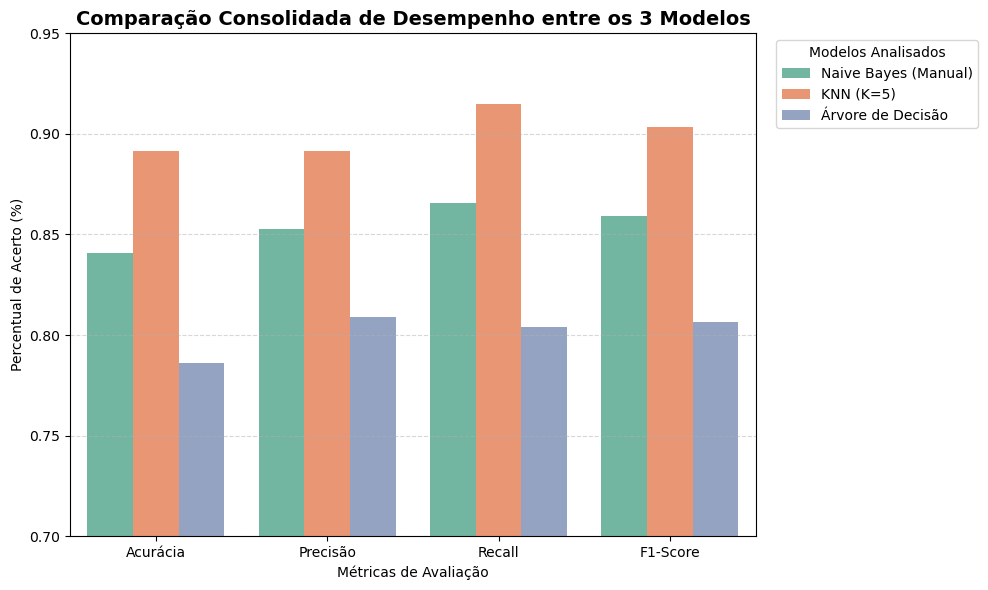

In [67]:
# 1. Definir os valores obtidos no seu Naive Bayes manual
# (Atualize estas variáveis se as suas métricas calculadas no Naive Bayes forem ligeiramente diferentes)
acuracia_nb = 0.8406
precisao_nb = 0.8529
recall_nb = 0.8657
f1_nb = 0.8593

# 2. Estruturar o dicionário de dados unificado
dados_comparativos = {
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Naive Bayes (Manual)': [acuracia_nb, precisao_nb, recall_nb, f1_nb],
    'KNN (K=5)': [metrics_knn['Acurácia'], metrics_knn['Precisão'], metrics_knn['Recall'], metrics_knn['F1-Score']],
    'Árvore de Decisão': [metrics_dt['Acurácia'], metrics_dt['Precisão'], metrics_dt['Recall'], metrics_dt['F1-Score']]
}

# 3. Criar e formatar o DataFrame comparativo
df_comparacao = pd.DataFrame(dados_comparativos)

print("=== TABELA COMPARATIVA DE DESEMPENHO ===")
# Exibe a tabela formatando os valores numéricos como porcentagem elegante
display(df_comparacao.style.format({
    'Naive Bayes (Manual)': '{:.2%}',
    'KNN (K=5)': '{:.2%}',
    'Árvore de Decisão': '{:.2%}'
}).hide(axis='index'))

# 4. Transformar o formato da tabela para facilitar a plotagem no Seaborn (Melt)
df_melted = df_comparacao.melt(id_vars='Métrica', var_name='Modelo', value_name='Pontuação')

# 5. Plotar o gráfico de barras comparativo lado a lado
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Métrica', y='Pontuação', hue='Modelo', palette='Set2')

# Ajustes estéticos do gráfico
plt.title('Comparação Consolidada de Desempenho entre os 3 Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Percentual de Acerto (%)')
plt.xlabel('Métricas de Avaliação')
plt.ylim(0.70, 0.95)  # Foca o zoom gráfico entre 70% e 95% para destacar as diferenças
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Modelos Analisados')
plt.tight_layout()
plt.show()